# Effective One-Dimensional Systems

In quantum mechanical models of complicated many-dimensional systems, it is often possible to consider an "effective system" which has reduced dimensionality. Consider, for example, how aromatic organic molecules are often reduced to their $\pi$-electron systems, which are then treated with a simplified model like [H&uml;ckel theory](https://en.wikipedia.org/wiki/H%C3%BCckel_method) or the [Pariser-Parr-Pople Hamiltonian](https://en.wikipedia.org/wiki/Pariser%E2%80%93Parr%E2%80%93Pople_method). While the [detailed logic behind $\pi$-electron approximation](https://doi.org/10.1063/1.1742733) is beyond the scope of this course, the key idea is that the low-energy spectroscopic and response properties of a system can often be understood using a reduced-dimensional model.

To see why this is the case, in this assignment, we consider arguably the simplest multidimensional Hamiltonian (the 2-dimensional particle in a box) and study under what circumstances it "appears" as if it were one-dimensional if one focusses on low-energy excitations. This helps explain why [we can treat molecules like the cyanine dyes as if they were one-dimensional systems](https://qchem.qc-edu.org/ParticleIn1DBox.html#cyanine-dyes), even though they are, of course, three-dimensional.

## A Particle in a Two-Dimensional Rectangular Box

For a [particle confined to a two-dimensional rectangular box of dimensions](https://qchem.qc-edu.org/ParticleInMultiD.html#the-2-dimensional-particle-in-a-box), defined by the potential function

$$
V(x,y) =
\begin{cases}
    +\infty & x\leq 0 \text{ or }y\leq 0 \\
    0       & 0\lt x \lt a_x \text{ and } 0 \lt y \lt a_y \\
    +\infty & a_x \leq x \text{ or } a_y \leq y
\end{cases}
$$

the Schr&ouml;dinger equaiton can be solved by separation of variables. Specifically, assume that the wavefunction, $\Psi(x,y)$ can be written as a product of the one-dimensional wavefunctions, $\psi(x) \cdot \phi(y)$ and substitute this into the Schr&ouml;dinger equation. Using the solution of the one-dimensional particle in a box, we see that the eigenenergies are the sum of the eigenenergies for the one-dimensional particle in a box,

$$
E_{n_x,n_y} = \frac{\hbar^2 \pi^2}{2m} \left(\frac{n_x^2}{a_x^2} + \frac{n_y^2}{a_y^2}\right)
$$

and the eigenfunctions of the product of the one-dimensional particle-in-a-box wavefunctions,

$$
\Psi_{n_x, n_y}(x, y)=\sqrt{\frac{2}{a_x}} \cdot \sqrt{\frac{2}{a_y}} \cdot \sin \left(\frac{n_x \pi x}{a_x}\right) \cdot \sin \left(\frac{n_y \pi y}{a_y}\right)
$$

## &#x1f469;&#x1f3fd;&#x200d;&#x1f4bb; Assignment: Complete the following notebook.

To do this, complete the code blocks indicated by `### START YOUR CODE HERE` and `### END YOUR CODE HERE` .

The detailed steps you'll follow are:

1. Complete the function `compute_1d_pib_solution` that returns the energy and wavefunction for a 1-dimensional electron in a box.
1. Complete the function `compute_2d_pib_solution` that returns the energy and wavefunction for a 2-dimensional electron in a box.
1. Plot the wavefunction using `plot_wavefunction`.
1. Complete the function `compute_max_n_y` that computes the number of levels in the $y$ direction, $n_y^{\max}$ that can be considered before an excitation in the $x$ direction (i.e., an increase from $n_x = 1$ to $n_x=2$ because favorable. You may assume that $0 \lt a_x \lt a_y < \infty$.
1. Upload your notebook and confirm its correctness. The marking scheme is provided at the end of this document.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def compute_1d_pib_solution(x, n, a):
    """
    Computes the eigenenergies and eigenfunctions at the point(x) x for
    an electron in a one-dimensonal box with 0 < x < a.

    The solutions are given in atomic units, in which hbar and the mass of the
    electron are equal to one.

    Parameters
    ----------
    x : float or array
        The position(s) of the particle
    n : int
        The quantum number
    a : float
        Length of the box. The box is defined as 0 < x < a.
    """
    # check argument n
    if not (isinstance(n, int) and n > 0):
        raise ValueError("Argument n should be a positive integer.")
    # check argument a
    if a <= 0.0:
        raise ValueError("Argument a should be positive.")
    # check argument x
    if not (isinstance(x, float) or hasattr(x, "__iter__")):
        raise ValueError("Argument x should be a float or an array!")

    # compute wave-function
    ### START CODE HERE
    A_n = np.sqrt(2.0 / a)
    psi =  A_n * np.sin(n * np.pi * x / a)

    ### END CODE HERE

    # compute energy
    ### START CODE HERE
    e = (n**2 * np.pi**2) / (2.0 * a**2)

    ### END CODE HERE

    # set wave-function values out of the box equal to zero
    if hasattr(x, "__iter__"):
        psi[x > a] = 0.0
        psi[x < 0] = 0.0
    else:
        if x < 0.0 or x > a:
            psi = 0.0
    return e, psi

In [ ]:
def compute_2d_pib_solution(x, y, n_x, n_y, a_x, a_y):
    """
    Computes the eigenenergies and eigenfunctions at the point(s) (x,y) for
    an electron in a two-dimensonal box with 0 < x < a_x and 0 < y < a_y

    The solutions are given in atomic units, in which hbar and the mass of the
    electron are equal to one.

    Parameters
    ----------
    x : float or array
        The position(s) of the particle in the x dimension
    y : float or array
        The position(s) of the particle in the y dimension
    n_x : int
        The quantum number for the x direction.
    n_y : int
        The quantum number for the y direction
    a_x : float
        Length of the box at along x-axis.
    a_y : float
        Length of the box at along y-axis.
    """
    # check argument n_x
    if not (isinstance(n_x, int) and n_x > 0):
        raise ValueError("Argument n_x should be a positive integer.")
    # check argument n_y
    if not (isinstance(n_y, int) and n_y > 0):
        raise ValueError("Argument n_y should be a positive integer.")
    # check argument a
    if a_x <= 0.0 or a_y <= 0.0:
        raise ValueError("Argument a should be positive.")
    # check argument x
    if not (isinstance(x, float) or hasattr(x, "__iter__")):
        raise ValueError("Argument x should be a float or an array!")
    # check argument y
    if not (isinstance(y, float) or hasattr(y, "__iter__")):
        raise ValueError("Argument y should be a float or an array!")

    # compute wave-function
    ### START CODE HERE
    e_x, psi_x = compute_1d_pib_solution(x, n_x, a_x)
    e_y, psi_y  =compute_1d_pib_solution(y, n_y, a_y)
    psi =  psi_x * psi_y
    e = e_x + e_y
    ### END CODE HERE

    return e, psi

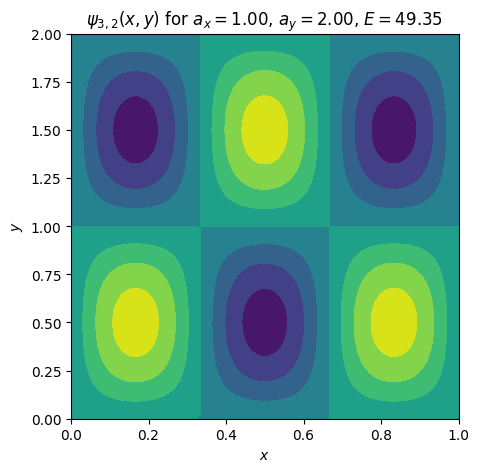

In [ ]:
def plot_wavefunction(n_x, n_y, a_x, a_y):
    """
    Plots the wavefunction for quantum numbers n_x and n_y for an electron in a box defined by
    0 < x < a_x and 0 < y < a_y.

    Parameters
    ----------
    n_x : int
        The quantum number for the x direction.
    n_y : int
        The quantum number for the y direction
    a_x : float
        Length of the box at along x-axis.
    a_y : float
        Length of the box at along y-axis.
    """
    # check argument n_x
    if not (isinstance(n_x, int) and n_x > 0):
        raise ValueError("Argument n_x should be a positive integer.")
    # check argument n_y
    if not (isinstance(n_y, int) and n_y > 0):
        raise ValueError("Argument n_y should be a positive integer.")
    # check argument a
    if a_x <= 0.0 or a_y <= 0.0:
        raise ValueError("Argument a should be positive.")

    # create grid
    x = np.linspace(0.0, a_x, 100)
    y = np.linspace(0.0, a_y, 100)
    X, Y = np.meshgrid(x, y)

    # compute wave-function
    ### START CODE HERE
    e, psi =  compute_2d_pib_solution(X, Y, n_x, n_y, a_x, a_y)

    ### END CODE HERE

    # plot wave-function
    fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
    ax.contourf(X, Y, psi)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(
        rf"$\psi_{{{n_x},{n_y}}}(x,y)$ for $a_x={a_x:.2f}$, $a_y={a_y:.2f}$, $E = {e:.2f}$"
    )
    plt.show()


n_x, n_y = 3, 2
a_x, a_y = 1, 2
plot_wavefunction(n_x, n_y, a_x, a_y)

## For what values of $a_y > a_x$ and $n_y$ is this effectively a one-dimensional particle-in-a-box?S+

- The ground state of the system has $n_x = n_y = 1$.
- Assuming, without loss of generality, that $a_y > a_x$, then the next lowest-energy state is $n_x = 1; n_y = 2$.
- The system "appears one-dimensional" as long as the low-energy states do not involve excitation of the $n_x$ quantum number. That is, for every value of $n_y$ such that $E_{n_x=1;n_y} < E_{n_x=2,n_y=1}$, the spacing of the system's energy levels are indistinguishable from that of a one-dimension particle in a box with width $a_y$.
- Let $n_y^{\max}$ be the largest value of $n_y$ for which $E_{n_x=1;n_y} < E_{n_x=2,n_y=1}$. We can find this value by testing the value of $E_{n_x=1;n_y} < E_{n_x=2,n_y=1}$ for $n_y = 2,3,\ldots$ until the inequality is violated. I.e., what is the largest value of $n_y$, $n_y^{\max}$, for which $E_{n_x=1;n_y^{\max}} < E_{n_x=2,n_y=1}$. In the next function you will compute the value of $n_y^{\max}$.


In [1]:
# function to compute the maximum excitation level for n_y before the system stops looking one-dimensional.
def compute_max_n_y(a_x, a_y):
    """
    Computes the maximum excitation level in the y direction that can be considered before the energy spectrum of a particle
    in a box with a_y > a_x > 0 is manifestly two-dimensional.

    Parameters
    ----------
    a_x : float
        Lenght of the box at along x-axis
    a_y : float
        Length of the box at along y-axis
    """
    # check arguments a_x, a_y
    if a_x < 0.0 or a_y < 0.0:
        raise ValueError("Argument a should be positive.")
    if a_x > a_y:
        raise ValueError("Argument a_x should not be larger than a_y.")

    if a_x > a_y:
        raise ValueError("Argument a_x should not be lower than a_y.")

    # compute maximum excitation level
    ### START CODE HERE

    n_max_y = 1
    while True:
        # Energy for (n_x=1, n_y=n_max_y+1)
        E_1_ny = (n_max_y + 1)**2 / a_y**2 + 1.0 / a_x**2
        # Energy for (n_x=2, n_y=1)
        E_2_1 = 4.0 / a_x**2 + 1.0 / a_y**2

        if E_1_ny >= E_2_1:
            break
        n_max_y += 1

    return n_max_y
    ### END CODE HERE

### &#x1f914; Thought-Provoking Questions

- Explain, in words, when it is possible to reduced a multi-dimensional system to a one-dimensional effective Hamiltonian?
- An alternative expression for the number of states for which the 1-dimensional approximation is acceptable is below. Explain how this expression is derived. Note that the `floor` function is the integer less than the a given number. E.g., `floor`(3.7) = 3. The assumption here is that $a_x < a_y$.

$$
n_y = \texttt{floor}\left(\sqrt{3 \frac{a_y^2}{a_x^2}+1}\right)
$$

- In the units considered here, $\hbar = m_e = 1$, the length of the cyanine dyes is given by the expression below, where $k-1$ is the number of conjugated double bonds. Make a table, in markdown, showing how the number of states for which the cyanine dyes are "effectively one-dimensional" changes as a function of $k$. Do this at least for $k=1,2,3,\ldots,6$. Compare this number to the number of occupied levels (which is the number of $pi$ electrons divided by two).

$$
a = \left(10.71 + 4.71 (k + 1)\right) \text{ Bohr}
$$


## &#x2696;&#xfe0f; Marking Scheme
&#x2611;&#xfe0f; Successful completion of the notebook, together with the ability to discuss your strategy, earns an **S**.  

&#x1f4b0; For an **S+**, answer the thought-provoking questions. Add markdown cells to complete these tasks. You can add images of hand-written answers to the markdown cells if you prefer, but write neatly.

### &#x1f914; Thought-Provoking Questions **Answers**

- Explain, in words, when it is possible to reduced a multi-dimensional system to a one-dimensional effective Hamiltonian?

It is possible to reduce a multi-dimensional system to a 1D effective Hamiltonian when the energy spacing in one direction is much larger than in all other directions that the system remains frozen in the ground state of those high-energy directions. In the 2D particle-in-a-box example, when $a_x \ll a_y$, the energy gap between $n_x = 1$ and $n_x = 2$ is enormous compared to the $y$-direction spacing. This means:

$$E_{{n_x}=1;{n_y}<{n_x=2};{n_y}=1}$$

for a large range of $N$, so all accessible excitations occur only in the $y$-direction with $n_x$ fixed at 1. The $x$-degree of freedom is effectively frozen out, and the system behaves as a 1D Hamiltonian in $y$ alone.

- An alternative expression for the number of states for which the 1-dimensional approximation is acceptable is below. Explain how this expression is derived. Note that the `floor` function is the integer less than the a given number. E.g., `floor`(3.7) = 3. The assumption here is that $a_x < a_y$.

$$
n_y = \texttt{floor}\left(\sqrt{3 \frac{a_y^2}{a_x^2}+1}\right)
$$

The 1D approximation holds as long as increasing $n_y$ is energetically cheaper than exciting $n_x$ to its first excited state ($n_x = 2$). Thus, the boundary condition is:

$$E_{n_x=1,\, n_y} < E_{n_x=2,\, n_y=1}$$

Substituting the 2D particle-in-a-box energies:

$$E_{n_x, n_y} = \frac{\hbar^2\pi^2}{2m}\left(\frac{n_x^2}{a_x^2} + \frac{n_y^2}{a_y^2}\right)$$

and cancelling the common prefactor:

$$\frac{1}{a_x^2} + \frac{n_y^2}{a_y^2} < \frac{4}{a_x^2} + \frac{1}{a_y^2}$$

Rearranging for $n_y$:

$$\frac{n_y^2}{a_y^2} < \frac{3}{a_x^2} + \frac{1}{a_y^2}$$

$$n_y^2 < 3\frac{a_y^2}{a_x^2} + 1$$

$$n_y < \sqrt{3\frac{a_y^2}{a_x^2} + 1}$$

Since $n_y$ must be a positive integer, we take the floor to obtain the largest valid $n_y$:

$$n_y = \texttt{floor}\left(\sqrt{3\frac{a_y^2}{a_x^2}+1}\right)$$


- In the units considered here, $\hbar = m_e = 1$, the length of the cyanine dyes is given by the expression below, where $k-1$ is the number of conjugated double bonds. Make a table, in markdown, showing how the number of states for which the cyanine dyes are "effectively one-dimensional" changes as a function of $k$. Do this at least for $k=1,2,3,\ldots,6$. Compare this number to the number of occupied levels (which is the number of $pi$ electrons divided by two).

$$
a = \left(10.71 + 4.71 (k + 1)\right) \text{ Bohr}
$$

The 1D approximation is valid as long as the occupied levels fall below $n_y = \texttt{floor}\left(\sqrt{3\frac{a_y^2}{a_x^2}+1}\right)$, where $a_x \approx 1$ Bohr (width of the $\pi$ orbital perpendicular to the chain) and $a_y = 10.71 + 4.71(k+1)$ Bohr. The number of occupied levels is $k+3$ (since there are $2(k+3)$ $\pi$ electrons).

| $k$ | $a_y$ (Bohr) | $\pi$ electrons | Occupied levels | 1D valid up to $n_y$ |
|-----|-------------|-----------------|-----------------|----------------------|
| 1   | 20.13       | 8               | 4               | 34                   |
| 2   | 24.84       | 10              | 5               | 43                   |
| 3   | 29.55       | 12              | 6               | 51                   |
| 4   | 34.26       | 14              | 7               | 59                   |
| 5   | 38.97       | 16              | 8               | 67                   |
| 6   | 43.68       | 18              | 9               | 75                   |

The 1D approximation is valid up to $n_y$ values of 34–75, while the number of occupied levels is only 4–9. Since the occupied levels are always far below the 1D validity threshold, the 1D particle-in-a-box model is a great approximation for cyanine dyes for all values of $k$ considered. This is because $a_y \gg a_x$, so exciting the $x$-direction costs far more energy than any $\pi$-electron transition along the chain would ever require.
